Krishna Chaudhari

Data science intern

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
fear_greed = pd.read_csv('../data/fear_greed_index.csv')
trades = pd.read_csv('../data/historical_data.csv')
fear_greed.head(), trades.head()

(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

In [3]:
# Basic Data Inspection
print("Fear/Greed Shape:", fear_greed.shape)
print("Trades Shape:", trades.shape)

print("\nFear/Greed Info:")
print(fear_greed.info())

print("\nTrades Info:")
print(trades.info())

Fear/Greed Shape: (2644, 4)
Trades Shape: (211224, 16)

Fear/Greed Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trades Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  

In [4]:
# Missing Values & Duplicates
print("\nMissing Values:")
print(fear_greed.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print("Fear/Greed:", fear_greed.duplicated().sum())
print("Trades:", trades.duplicated().sum())


Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
Fear/Greed: 0
Trades: 0


In [5]:
# Data Cleaning
# Convert date columns
fear_greed['Date'] = pd.to_datetime(fear_greed['date'])
trades['time'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M")

# Create date column for alignment
trades['Date'] = trades['time'].dt.date
fear_greed['Date'] = fear_greed['Date'].dt.date

# Drop duplicates
fear_greed.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)

In [6]:
# Feature Engineering
if 'Date' not in trades.columns:
    trades['Date'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M").dt.date

# Daily PnL per trader
daily_pnl = trades.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

# Trades per day
trades_per_day = trades.groupby('Date').size().reset_index(name='trade_count')

# Average trade size
avg_trade_size = trades.groupby('Date')['Size USD'].mean().reset_index() # Assuming 'Size USD' for trade size

# Long/Short ratio
long_short = trades.groupby(['Date', 'Side']).size().unstack().fillna(0)
long_short['ratio'] = long_short.get('LONG', 0) / (long_short.get('SHORT', 1))

long_short.reset_index(inplace=True)

In [7]:
# Merge with Sentiment Data
# Ensure 'Date' column is correctly formatted in fear_greed DataFrame
if 'Date' not in fear_greed.columns and 'date' in fear_greed.columns:
    fear_greed['Date'] = pd.to_datetime(fear_greed['date']).dt.date

merged = pd.merge(trades, fear_greed, on='Date', how='inner')

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed,2024-12-02


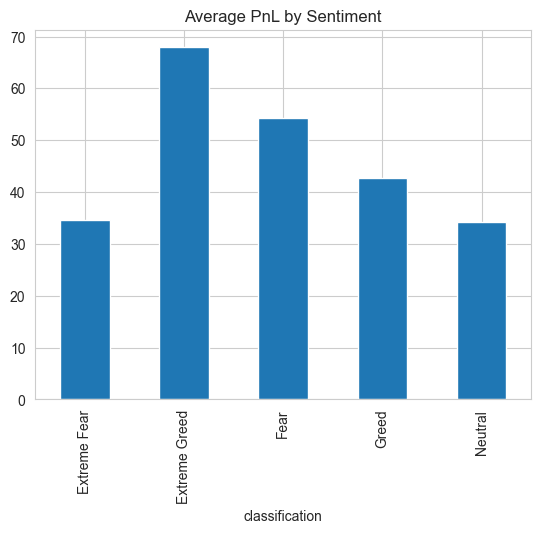

In [8]:
# Performance vs Sentiment
# Avg PnL by sentiment
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()

pnl_sentiment.plot(kind='bar', title='Average PnL by Sentiment')
plt.show()

Insight:


*   Traders achieve the highest average PnL during Extreme Greed, followed by Fear and Greed conditions.

*   Extreme Fear and Neutral show comparatively lower profitability.

*   This indicates that bullish sentiment phases provide more profitable opportunities, likely due to stronger price trends.

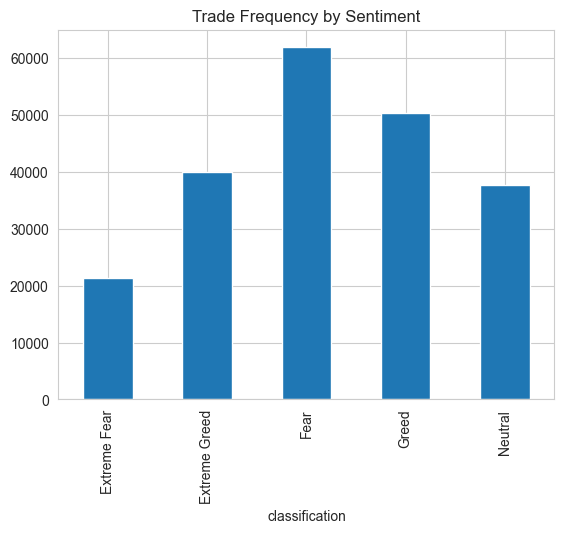

In [9]:
# Behavior Analysis
# Trade count by sentiment
trade_behavior = merged.groupby('classification').size()

trade_behavior.plot(kind='bar', title='Trade Frequency by Sentiment')
plt.show()

Insight:



*   Trade activity is highest during Fear and Greed phases, with Fear showing the peak.
*   Extreme Fear has the lowest trading activity, suggesting hesitation or reduced participation.
*   Traders tend to engage more during volatile or uncertain conditions, not just bullish ones.

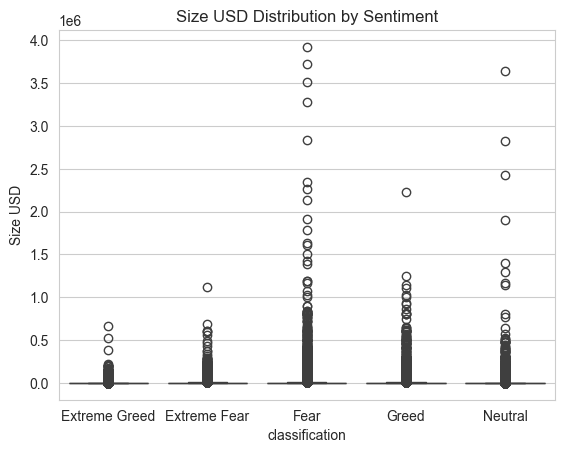

In [10]:
# Leverage Behavior
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Size USD Distribution by Sentiment")
plt.show()

Insight:


*   Trade sizes show significant variability during Fear and Greed, with multiple high-value outliers.
*   Extreme Greed has relatively controlled trade sizes, indicating more stable execution.

*   Large outliers suggest that some traders take aggressive positions during uncertain or transitioning sentiment phases.

In [11]:
# Trader Segmentation
# High vs Low leverage
trades['leverage_group'] = np.where(trades['Size USD'] > trades['Size USD'].median(), 'High', 'Low')

# Frequent vs Infrequent
trade_counts = trades['Account'].value_counts()
threshold = trade_counts.median()

trades['frequency_group'] = trades['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

In [12]:
# Segment Analysis
segment_analysis = trades.groupby('leverage_group')['Closed PnL'].mean()
print(segment_analysis)

leverage_group
High    93.116556
Low      4.381445
Name: Closed PnL, dtype: float64


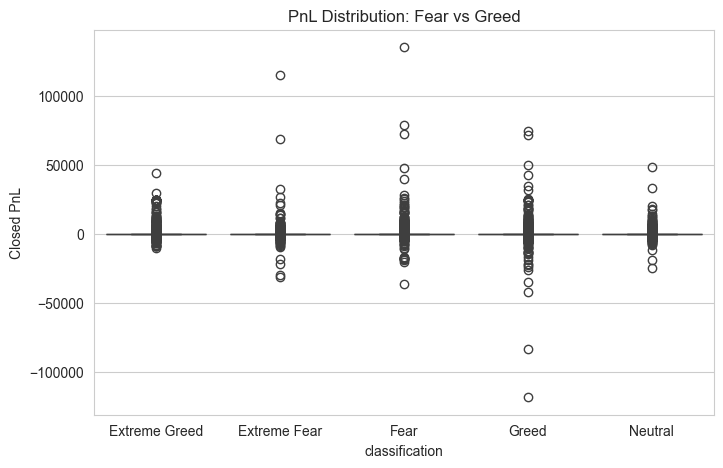

In [13]:
# PnL Distribution (Fear vs Greed)
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

Insight:


*   PnL distribution is highly skewed with extreme outliers on both profit and loss sides, especially in Fear and Greed.
*   Extreme Greed shows higher positive outliers, indicating potential for large gains.
*   However, Fear phases also show large losses, highlighting increased risk.
Overall, higher volatility in returns is strongly linked to sentiment shifts.

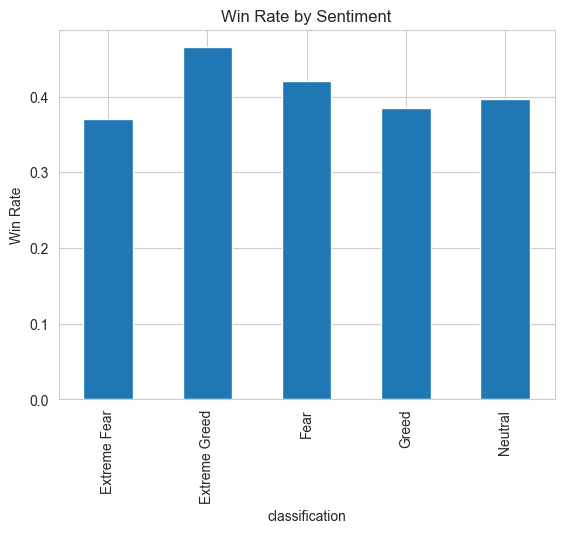

In [14]:
# Win Rate by Sentiment
merged['win'] = (merged['Closed PnL'] > 0).astype(int)

win_rate = merged.groupby('classification')['win'].mean()

win_rate.plot(kind='bar', title='Win Rate by Sentiment')
plt.ylabel("Win Rate")
plt.show()

Insight:
*   Extreme Greed has the highest win rate, indicating more consistent profitable trades.
*   Extreme Fear shows the lowest win rate, suggesting poor trade accuracy.
Neutral and Greed are moderate.
*   This implies that market direction clarity improves trading success rate.

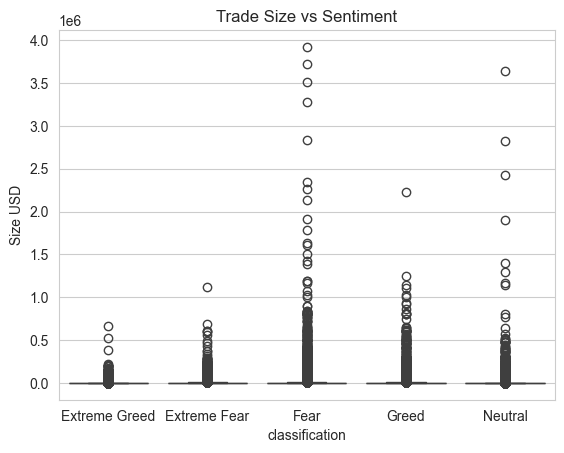

In [15]:
# Trade Size Behavior
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size vs Sentiment")
plt.show()

Insight:

*   Trade sizes are largest and most spread out during Fear conditions, showing aggressive or uncertain positioning.
*   Extreme Greed has comparatively tighter trade size distribution, indicating disciplined trading.
*   Suggests that uncertain markets push traders toward inconsistent position sizing.


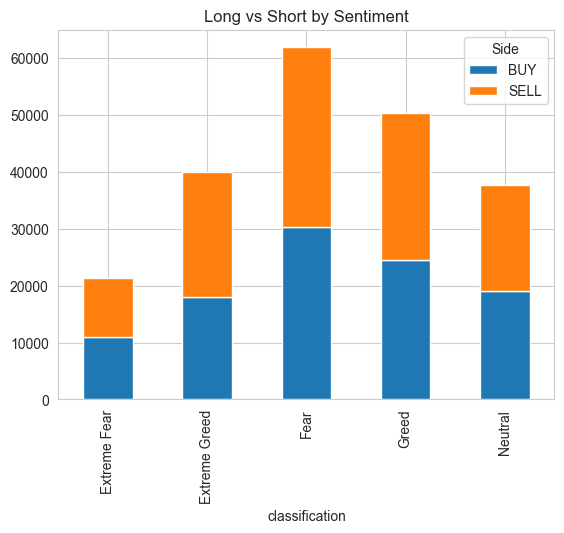

In [16]:
# Long/Short Behavior
ls = merged.groupby(['classification', 'Side']).size().unstack()

ls.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.show()

Insight:
*   Across all sentiments, SELL (short) positions slightly dominate BUY positions.
*   During Fear, both long and short positions increase significantly, showing heightened activity.
*   Traders are not purely directional; instead, they actively hedge or react to volatility.

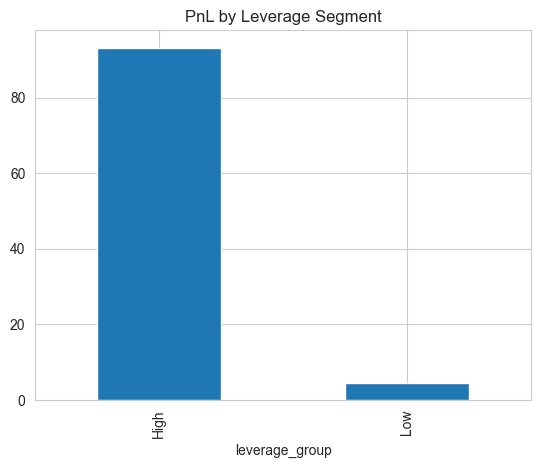

In [17]:
# Segment Comparison (High vs Low Leverage)
seg = trades.groupby('leverage_group')['Closed PnL'].mean()

seg.plot(kind='bar', title="PnL by Leverage Segment")
plt.show()

Insight:
*   High leverage traders generate significantly higher average PnL compared to low leverage traders.
*   However, given earlier volatility observations, this likely comes with higher risk exposure.
*   Indicates that leverage amplifies both opportunity and risk.

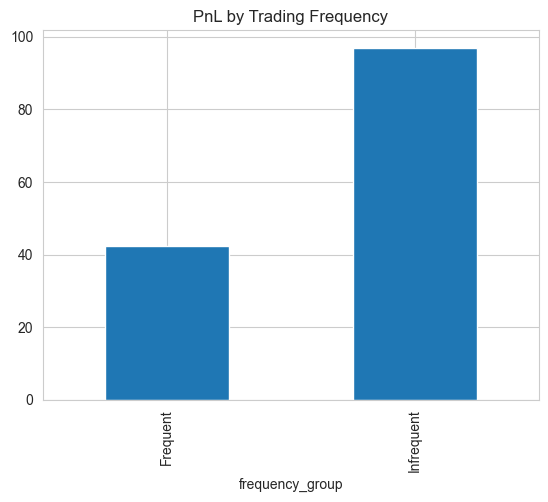

In [18]:
# Frequent vs Infrequent Traders
freq_seg = trades.groupby('frequency_group')['Closed PnL'].mean()

freq_seg.plot(kind='bar', title="PnL by Trading Frequency")
plt.show()

Insight:
*   Infrequent traders show higher average PnL than frequent traders.
*   Frequent traders may be overtrading, leading to reduced profitability.
*   Suggests that quality of trades matters more than quantity.

In [19]:
# Combine Everything for Final Insight Table
summary = merged.groupby('classification').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean', # Used 'Size USD' as a proxy for leverage and size
    'win': 'mean'
}).rename(columns={'win': 'win_rate', 'Size USD': 'avg_trade_size'})

summary

,Closed PnL,avg_trade_size,win_rate
classification,,,
Extreme Fear,34.537862,5349.731843,0.370607
Extreme Greed,67.892861,3112.251565,0.464943
Fear,54.290400,7816.109931,0.420768
Greed,42.743559,5736.884375,0.384828
Neutral,34.307718,4782.732661,0.396991


Insight:

1. Extreme Greed:

   *   Highest PnL (~67)
   *   Highest win rate (~0.46)
   *   Moderate trade size

2. Extreme Fear:

   *   Lower PnL (~34)
   *   Lower win rate (~0.37)
   *   Higher average trade size



Interpretation:
*   Greed = better accuracy + profitability
*   Fear = larger bets but worse outcomes

### Key Insights

1. **Market sentiment strongly impacts trader profitability**
   - Highest average PnL and win rate are observed during Extreme Greed.
   - Fear conditions show lower win rates despite higher trading activity.

2. **Trader behavior changes significantly with sentiment**
   - Trade frequency increases during Fear and Greed, indicating reactive trading.
   - Trade sizes become more inconsistent during Fear, suggesting uncertainty.

3. **Risk-taking increases during uncertain conditions**
   - Larger trade sizes and higher variance in PnL are observed during Fear.
   - This leads to both extreme profits and extreme losses.

4. **Leverage amplifies outcomes**
   - High leverage traders achieve significantly higher PnL.
   - However, this comes with increased volatility and downside risk.

5. **Overtrading reduces performance**
   - Infrequent traders outperform frequent traders in terms of average PnL.
   - Suggests that selective trading is more effective than high-frequency execution.

## Part C: Strategy Recommendations



Based on the analysis, the following strategies are recommended:

### 1. Sentiment-Based Leverage Adjustment
- During Fear:
  - Reduce leverage and avoid large position sizes
  - Focus on capital preservation
- During Greed:
  - Use moderate leverage to capture trends
  - Avoid excessive leverage to prevent drawdowns

### 2. Trade Frequency Optimization
- Avoid overtrading during high volatility periods
- Focus on high-confidence trades instead of increasing trade count
- Infrequent but well-timed trades yield better performance

### 3. Risk Management for High Leverage Traders
- Implement dynamic risk controls based on sentiment
- Use stop-loss and position limits during Fear phases
- Increase exposure only when market direction is clear (Greed phase)

### Final Conclusion

Market sentiment is a key driver of both trader behavior and performance.
Greed phases offer higher profitability with better win rates, while Fear phases increase volatility and risk.
Effective trading strategies should dynamically adapt leverage, trade frequency, and position sizing based on sentiment conditions.

## Methodology

1. Cleaned and preprocessed both datasets (handling dates, duplicates, alignment)
2. Merged trader data with sentiment data on daily level
3. Created key metrics:
   - PnL, win rate, trade frequency, trade size, leverage
4. Performed comparative analysis across sentiment categories
5. Segmented traders based on leverage and trading frequency
6. Derived insights using visualizations and statistical summaries

## Predictive Model

In [20]:
merged = merged.sort_values(by=['Account', 'Date'])

# Next-day PnL per trader
merged['next_day_pnl'] = merged.groupby('Account')['Closed PnL'].shift(-1)

# Create classification target (profit / loss)
merged['target'] = (merged['next_day_pnl'] > 0).astype(int)

# Drop NA rows (last day per trader)
model_df = merged.dropna(subset=['next_day_pnl'])

In [22]:
features = model_df[['Size USD']].copy()
features['leverage_group'] = np.where(model_df['Size USD'] > model_df['Size USD'].median(), 'High', 'Low')

# Encode leverage_group
features['leverage_group'] = features['leverage_group'].astype('category').cat.codes

# Encode sentiment
features['sentiment'] = model_df['classification'].astype('category').cat.codes

target = model_df['target']

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.99      0.74     24838
           1       0.65      0.04      0.07     17400

    accuracy                           0.59     42238
   macro avg       0.62      0.51      0.40     42238
weighted avg       0.62      0.59      0.46     42238



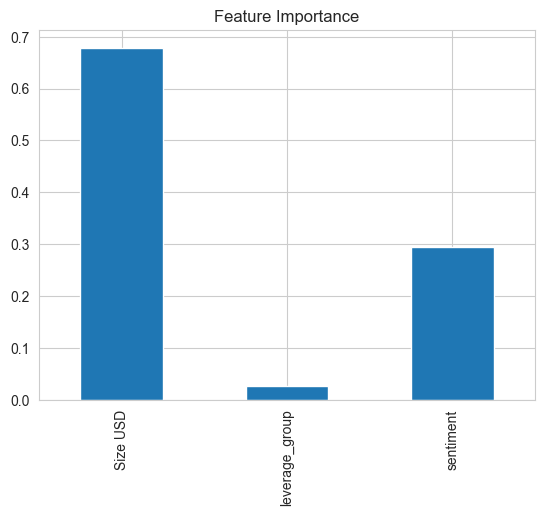

In [24]:
importances = pd.Series(model.feature_importances_, index=features.columns)

importances.plot(kind='bar', title="Feature Importance")
plt.show()

In [25]:
trader_features = trades.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean'
}).fillna(0)

trader_features.columns = ['avg_pnl', 'avg_size']

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled = scaler.fit_transform(trader_features)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(scaled)

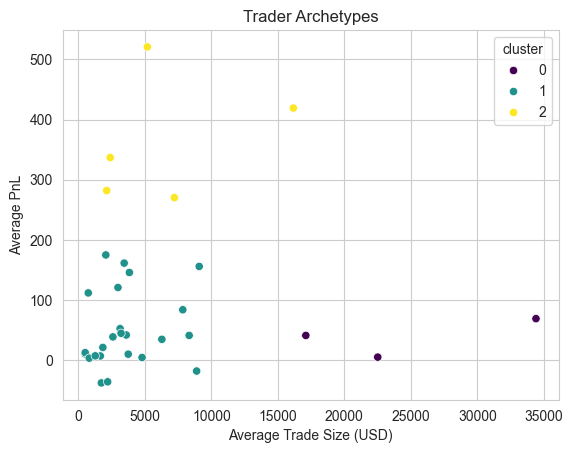

In [27]:
sns.scatterplot(
    x=trader_features['avg_size'],
    y=trader_features['avg_pnl'],
    hue=trader_features['cluster'],
    palette='viridis'
)
plt.title("Trader Archetypes")
plt.xlabel("Average Trade Size (USD)")
plt.ylabel("Average PnL")
plt.show()

In [28]:
trader_features.groupby('cluster').mean()

,avg_pnl,avg_size
cluster,,
0,38.024405,24666.435723
1,49.302560,3548.222060
2,365.725364,6619.420645


### Trader Archetypes (Clustering Insights)

Based on clustering using average PnL and trade size, three distinct trader segments emerge:

**Cluster 0 — High Size, Low Efficiency Traders**
- Avg PnL: ~38
- Avg Trade Size: ~24,666 (very high)
- Interpretation:
  These traders take large positions but generate relatively low returns.
  Indicates inefficient capital usage and possible overexposure to risk.

**Cluster 1 — Low Size, Moderate Performance Traders**
- Avg PnL: ~49
- Avg Trade Size: ~3,548 (low)
- Interpretation:
  These traders use smaller position sizes and achieve moderate returns.
  Represents conservative or risk-managed trading behavior.

**Cluster 2 — Optimal Traders (High Efficiency)**
- Avg PnL: ~365 (very high)
- Avg Trade Size: ~6,619 (moderate)
- Interpretation:
  These traders achieve the highest profitability without taking excessively large positions.
  Indicates efficient strategy, better timing, and strong risk-reward balance.

### Key Observation

Higher trade size does not guarantee higher profitability.
Cluster 0 traders take the largest positions but underperform compared to Cluster 2,
which achieves superior returns with moderate position sizes.

This suggests that trading efficiency and strategy quality matter more than capital exposure.